In [10]:
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
path_baseline = "../data/analytics/model_results/GIR-EPM/con_exog/baseline/validation_metrics_all_steps_baseline.csv"
df_base_line = pd.read_csv(path_baseline)
df_base_line["model"] = df_base_line["model"].replace({"NaiveByLag": "Baseline"})
df_base_line.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,Baseline,17.660609,11.712266,311.897098,-0.268944,0.650088,"{""1"": 0.6500877962278535}"
1,2,Baseline,19.147625,12.984772,366.631538,-0.491630,0.720718,"{""1"": 0.6612382573917415, ""2"": 0.7810261158550..."
2,3,Baseline,20.455343,13.868641,418.421059,-0.702334,0.769777,"{""1"": 0.6581284721190482, ""2"": 0.8372760838919..."
3,4,Baseline,20.645793,14.576196,426.248775,-0.734181,0.809050,"{""1"": 0.682018555496663, ""2"": 0.81787790221401..."
4,5,Baseline,20.951675,14.629078,438.972699,-0.785948,0.811985,"{""1"": 0.7095320207041961, ""2"": 0.7766535762374..."


In [12]:
path_lstm = "../data/analytics/model_results/GIR-EPM/con_exog/lstm/validation_metrics_all_steps_direct.csv"
df_lstm = pd.read_csv(path_lstm)
df_lstm.head()


,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LSTM,12.370528,9.265004,153.029974,0.377402,0.514253,"{""1"": 0.5142528486760095}"
1,2,LSTM,13.126493,9.864763,172.304808,0.298983,0.547542,"{""1"": 0.5133116633449076, ""2"": 0.5822497946294..."
2,3,LSTM,13.679865,9.477292,187.138717,0.238631,0.526036,"{""1"": 0.47268007838934106, ""2"": 0.557518980013..."
3,4,LSTM,14.315076,11.245326,204.921410,0.166283,0.624170,"{""1"": 0.6061179217804306, ""2"": 0.5775442014669..."
4,5,LSTM,14.025007,10.222189,196.700815,0.199728,0.567381,"{""1"": 0.5117306654225292, ""2"": 0.5193304208547..."


In [13]:
path_direct = "../data/analytics/model_results/GIR-EPM/con_exog/direct/validation_metrics_all_steps_direct.csv"
df_direct = pd.read_csv(path_direct)
df_direct["model"] = df_direct["model"].replace(
    {"LGBM": "LGBM direct", "XGBoost": "XGBoost direct"}
)
df_direct.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LGBM direct,14.961411,10.083897,223.843813,0.089298,0.559705,"{""1"": 0.5597054156456861}"
1,1,LGBM direct,14.961411,10.083897,223.843813,0.089298,0.559705,"{""1"": 0.5597054156456861}"
2,1,XGBoost direct,14.856513,10.032671,220.715978,0.102023,0.556862,"{""1"": 0.5568621257859243}"
3,1,XGBoost direct,16.820387,11.188359,282.925421,-0.151074,0.621008,"{""1"": 0.6210083968076348}"
4,2,LGBM direct,14.048714,9.747740,197.366362,0.197021,0.541047,"{""1"": 0.5265514178522573, ""2"": 0.5557445490979..."


In [14]:
path_simple = "../data/analytics/model_results/GIR-EPM/con_exog/validation_metrics_all_steps_direct.csv"
df = pd.read_csv(path_simple)
df["model"] = df["model"].replace(
    {"LGBM": "LGBM recursive", "XGBoost": "XGBoost recursive"}
)


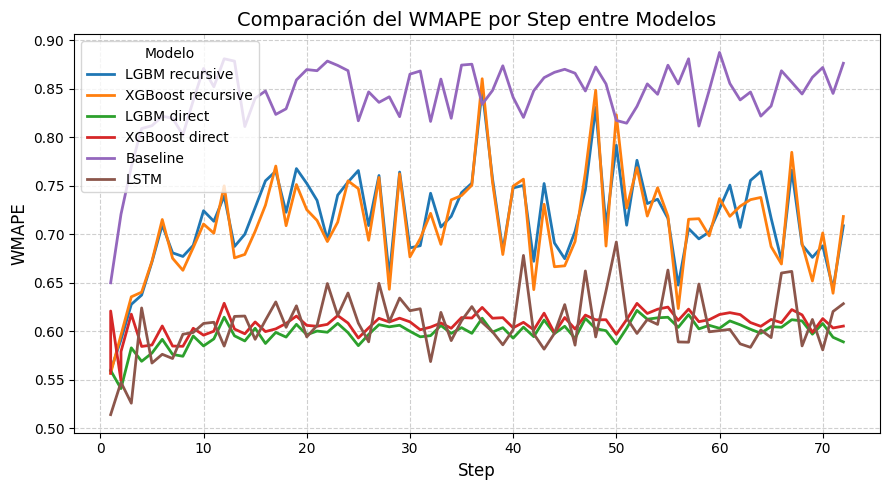

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Supongamos que ya tienes los dos DataFrames: df y df_base_line ---
# df contiene LGBM y XGBoost
# df_base_line contiene Baseline

# Si quieres verificar que ambos tienen las mismas columnas:
# print(df.columns)
# print(df_base_line.columns)

# --- Unir los dos DataFrames ---
df_all = pd.concat([df, df_direct, df_base_line, df_lstm], ignore_index=True)

# --- Graficar las tres líneas ---
plt.figure(figsize=(9, 5))

for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.plot(subset["step"], subset["wmape"], marker="", linewidth=2, label=model)

# --- Personalizar ---
plt.title("Comparación del WMAPE por Step entre Modelos", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("WMAPE", fontsize=12)
plt.legend(title="Modelo", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()
